# 🧬 Breast Cancer Cell Classification using SVM

## 📌 Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    jaccard_score,
    f1_score
)


C:\Users\User\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.8' currently installed).
  warnings.warn(msg, UserWarning)


## 📂 Load Dataset

In [2]:
# Load dataset
cell_df = pd.read_csv("cell_samples.csv")

# Display first few rows
cell_df.head()


,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## 📊 Exploratory Visualization

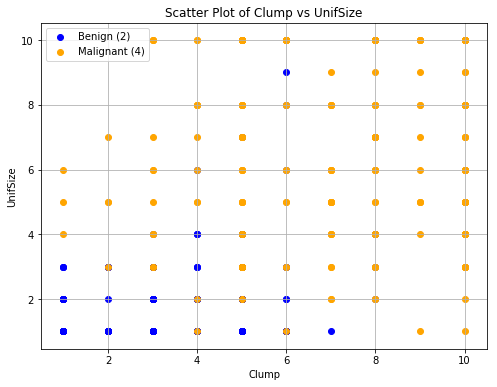

In [3]:
# Separate classes
benign = cell_df[cell_df["Class"] == 2]      # Benign class
malignant = cell_df[cell_df["Class"] == 4]   # Malignant class

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(benign["Clump"], benign["UnifSize"], color="blue", label="Benign (2)")
plt.scatter(malignant["Clump"], malignant["UnifSize"], color="orange", label="Malignant (4)")

plt.xlabel("Clump")
plt.ylabel("UnifSize")
plt.title("Scatter Plot of Clump vs UnifSize")
plt.legend()
plt.grid(True)
plt.show()


## 🔄 Data Cleaning

In [4]:
# Remove rows with missing values in 'BareNuc'
cell_df = cell_df[cell_df["BareNuc"] != "?"]

# Convert column to numeric
cell_df["BareNuc"] = cell_df["BareNuc"].astype(float)




## 🎯 Feature Selection and Target

In [5]:
X = cell_df[
    [
        "ID", "Clump", "UnifSize", "UnifShape", "MargAdh",
        "SingEpiSize", "BareNuc", "BlandChrom", "NormNucl", "Mit"
    ]
]

y = cell_df["Class"]


## 📏 Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 🔀 Train–Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=4,
    stratify=y
)


## 🧠 Train SVM Classifier

In [9]:
# Initialize SVM with RBF kernel
svm_model = SVC(kernel="rbf")

# Train model
svm_model.fit(X_train, y_train)


SVC()

## 🔮 Prediction

In [10]:
y_pred = svm_model.predict(X_test)


## 🔲 Confusion Matrix Visualization

In [12]:
def plot_confusion_matrix(
    cm,
    classes,
    normalize=False,
    title="Confusion Matrix",
    cmap=plt.cm.Blues
):
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix (not normalized)")

    print(cm)

    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()


Confusion matrix (not normalized)
[[83  6]
 [ 2 46]]


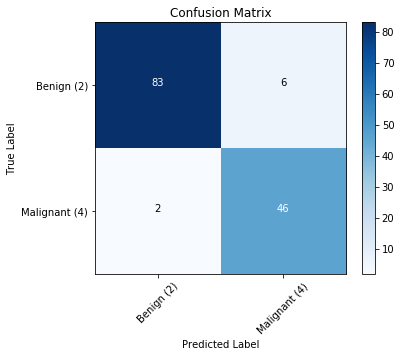

In [13]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred, labels=[2, 4])

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plot_confusion_matrix(
    cnf_matrix,
    classes=["Benign (2)", "Malignant (4)"],
    normalize=False,
    title="Confusion Matrix"
)

plt.show()


## 📈 Additional Metrics

In [14]:
jaccard = jaccard_score(y_test, y_pred, pos_label=2)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Jaccard Score (Benign as positive): {jaccard:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


Jaccard Score (Benign as positive): 0.9121
Weighted F1 Score: 0.9421
